# CSE432/532: Introduction to Machine Learning
## Take-Home Midterm Exam 2

**Allowed resources:** Python, NumPy, pandas, matplotlib, seaborn, scikit-learn, scipy
**Submission format:** Run all cells top-to-bottom, then save and submit as `Lastname_Firstname_CSE432_532_Midterm2.ipynb` via Canvas.

---

### Instructions

1. Fill in your first and last name in the Setup cell below.
2. Run **all** cells in order. Do **not** edit code or question cells unless a question specifically asks you to.
3. Write your answers in the highlighted answer cells (marked by a colored left border).
4. Round numeric results to **4 decimal places** unless stated otherwise.
5. All questions carry **equal weight**.
6. Plots are optimized for a **light color theme**.

In [1]:
# ============================================================
# STUDENT INFO -- fill in your name
# ============================================================
FIRST_NAME = "Dean"
LAST_NAME  = "DiCarlo"
print(f"Student: {FIRST_NAME} {LAST_NAME}")

Student: Dean DiCarlo


In [2]:
# ============================================================
# DO NOT EDIT -- Required imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, HuberRegressor, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn import metrics

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

<div style="border: 2px solid #2563eb; border-radius: 8px; padding: 16px 20px; margin: 24px 0 12px 0; background: rgba(37, 99, 235, 0.04);">

## Q1

Run the cell below to generate a 2x2 figure, then answer Q1.A through Q1.D.

</div>

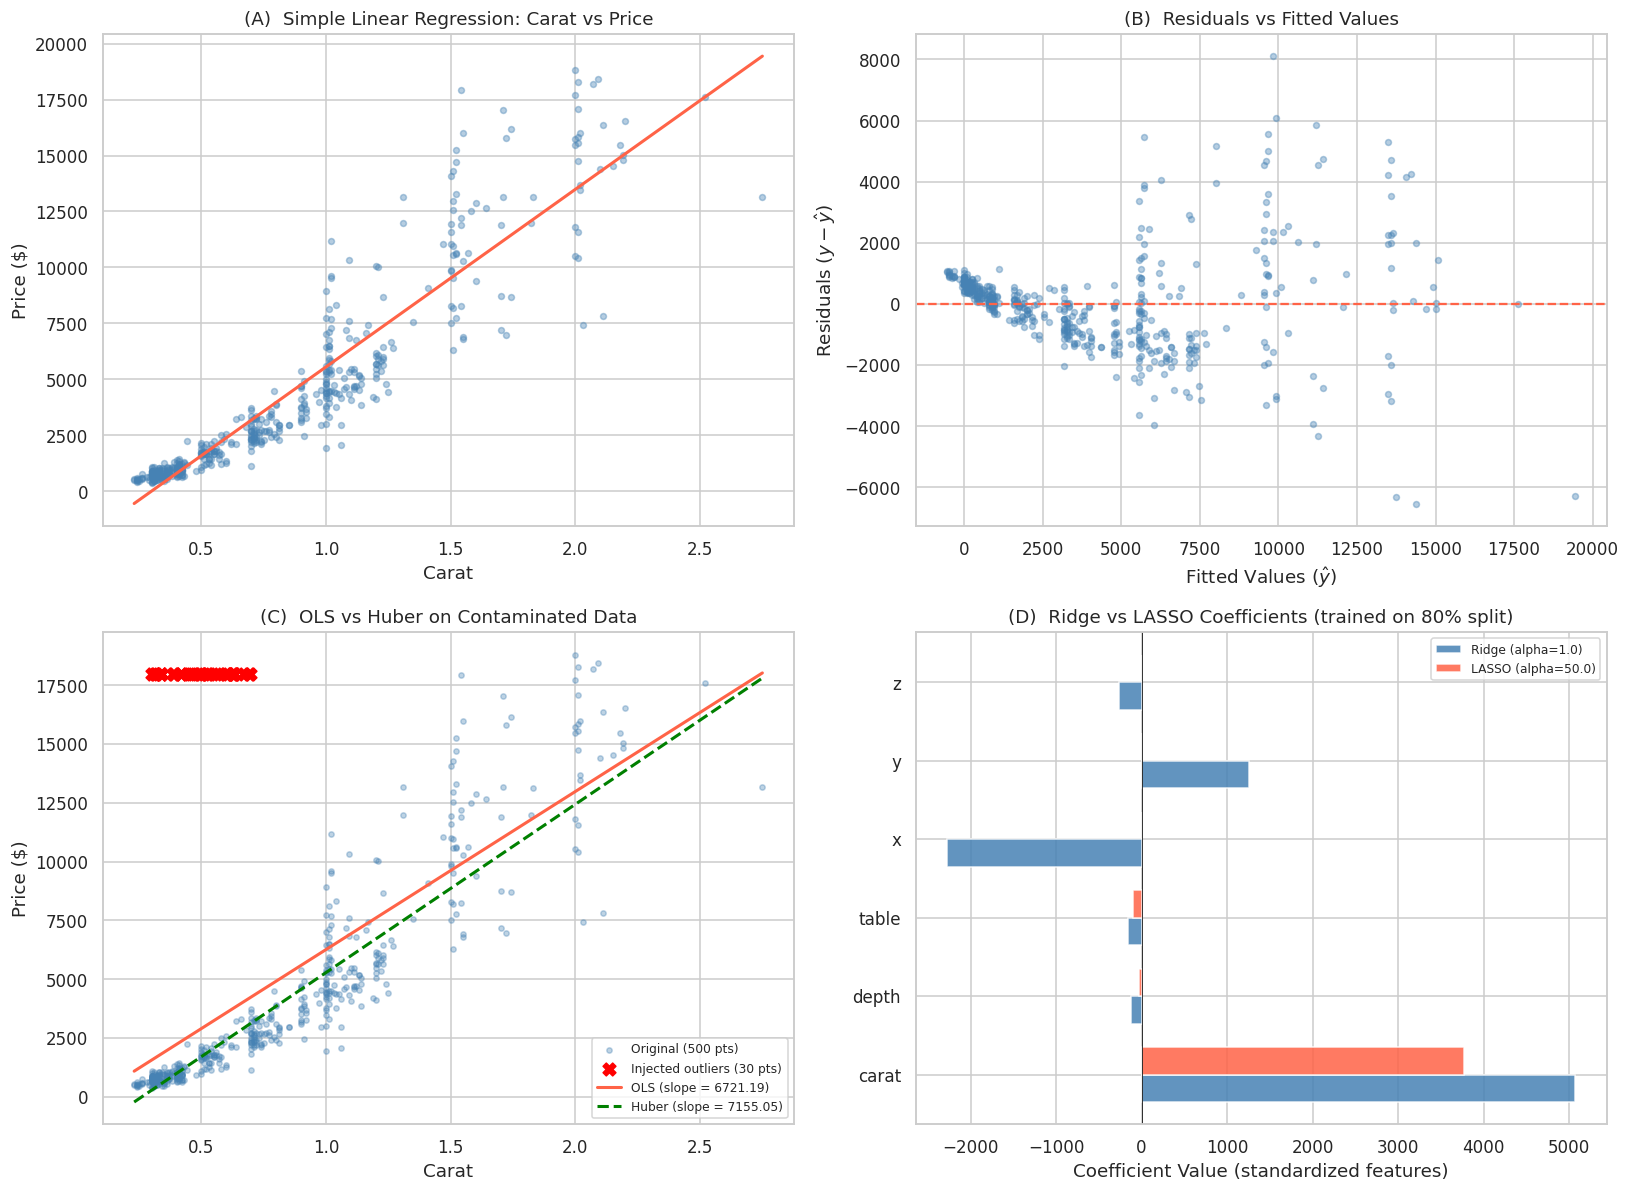

Panel (A) model:
  Intercept: -2377.9384    Slope: 7934.8325    R-squared: 0.8593

Panel (C) slope comparison:
  OLS  slope | clean: 7934.8325  | contaminated: 6721.1927  | change: 1213.6398
  Huber slope| clean: 7159.8422  | contaminated: 7155.0484  | change: 4.7937

Panel (D) coefficients (80/20 split):
     Feature |   Ridge |   LASSO
  ---------------------------------
       carat | 5069.94 | 3771.11
       depth | -127.46 |  -27.33
       table | -160.20 |  -95.48
           x | -2276.55 |   -0.00
           y | 1260.11 |   -0.00
           z | -263.65 |   -0.00

  Ridge -- train R2: -22.2014  test R2: -17.2879
  LASSO -- train R2: -0.3497  test R2: -0.3426


In [14]:
# ============================================================
# DO NOT EDIT -- Q1 Figure (2x2): Run this cell, then answer
#                the questions below based on the four panels.
# ============================================================
diamonds = sns.load_dataset('diamonds')
df = diamonds.sample(n=500, random_state=42).copy().reset_index(drop=True)

X = df[['carat']].values
y = df['price'].values

# --- Models for panels A & B ---
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
residuals = y - y_pred

# --- Outlier injection for panel C ---
np.random.seed(99)
outlier_carats = np.random.uniform(0.3, 0.7, (30, 1))
outlier_prices = np.full(30, 18000.0)
X_out = np.vstack([X, outlier_carats])
y_out = np.concatenate([y, outlier_prices])

ols_clean = LinearRegression().fit(X, y)
hub_clean = HuberRegressor().fit(X, y)
ols_dirty = LinearRegression().fit(X_out, y_out)
hub_dirty = HuberRegressor().fit(X_out, y_out)

# --- Regularization for panel D ---
num_features = ['carat', 'depth', 'table', 'x', 'y', 'z']
X_full = df[num_features].values
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42)
X_scaled = scaler.fit_transform(X_train)
ridge = Ridge(alpha=1.0).fit(X_scaled, y_train)
lasso = Lasso(alpha=50.0).fit(X_scaled, y_train)

# ----------------------- 2x2 Figure -----------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# --- Panel (A): Scatter + regression line ---
ax = axes[0, 0]
ax.scatter(X, y, alpha=0.4, s=15, color='steelblue')
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
ax.plot(x_range, model.predict(x_range), color='tomato', linewidth=2)
ax.set_xlabel('Carat')
ax.set_ylabel('Price ($)')
ax.set_title('(A)  Simple Linear Regression: Carat vs Price')

# --- Panel (B): Residuals vs fitted ---
ax = axes[0, 1]
ax.scatter(y_pred, residuals, alpha=0.4, s=15, color='steelblue')
ax.axhline(y=0, color='tomato', linewidth=1.5, linestyle='--')
ax.set_xlabel('Fitted Values ($\\hat{y}$)')
ax.set_ylabel('Residuals ($y - \\hat{y}$)')
ax.set_title('(B)  Residuals vs Fitted Values')

# --- Panel (C): OLS vs Huber on contaminated data ---
ax = axes[1, 0]
ax.scatter(X, y, alpha=0.35, s=12, color='steelblue', label='Original (500 pts)')
ax.scatter(outlier_carats, outlier_prices, color='red', s=70, marker='X',
           label='Injected outliers (30 pts)', zorder=5)
xr = np.linspace(X_out.min(), X_out.max(), 100).reshape(-1, 1)
ax.plot(xr, ols_dirty.predict(xr), color='tomato', linewidth=2,
        label=f'OLS (slope = {ols_dirty.coef_[0]:.2f})')
ax.plot(xr, hub_dirty.predict(xr), color='green', linewidth=2, linestyle='--',
        label=f'Huber (slope = {hub_dirty.coef_[0]:.2f})')
ax.set_xlabel('Carat')
ax.set_ylabel('Price ($)')
ax.set_title('(C)  OLS vs Huber on Contaminated Data')
ax.legend(fontsize=8, loc='lower right')

# --- Panel (D): Ridge vs LASSO coefficients ---
ax = axes[1, 1]
yp = np.arange(len(num_features))
h = 0.35
ax.barh(yp - h/2, ridge.coef_, h, label='Ridge (alpha=1.0)', color='steelblue', alpha=0.85)
ax.barh(yp + h/2, lasso.coef_, h, label='LASSO (alpha=50.0)', color='tomato', alpha=0.85)
ax.set_yticks(yp)
ax.set_yticklabels(num_features)
ax.set_xlabel('Coefficient Value (standardized features)')
ax.set_title('(D)  Ridge vs LASSO Coefficients (trained on 80% split)')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- Printed summaries ---
print("Panel (A) model:")
print(f"  Intercept: {model.intercept_:.4f}    Slope: {model.coef_[0]:.4f}    R-squared: {metrics.r2_score(y, y_pred):.4f}")
print()
print("Panel (C) slope comparison:")
print(f"  OLS  slope | clean: {ols_clean.coef_[0]:.4f}  | contaminated: {ols_dirty.coef_[0]:.4f}  | change: {abs(ols_dirty.coef_[0]-ols_clean.coef_[0]):.4f}")
print(f"  Huber slope| clean: {hub_clean.coef_[0]:.4f}  | contaminated: {hub_dirty.coef_[0]:.4f}  | change: {abs(hub_dirty.coef_[0]-hub_clean.coef_[0]):.4f}")
print()
print("Panel (D) coefficients (80/20 split):")
print(f"  {'Feature':>10s} | {'Ridge':>7s} | {'LASSO':>7s}")
print(f"  {'-'*33}")
for f, rc, lc in zip(num_features, ridge.coef_, lasso.coef_):
    print(f"  {f:>10s} | {rc:>7.2f} | {lc:>7.2f}")
print()
print(f"  Ridge -- train R2: {metrics.r2_score(y_train, ridge.predict(X_train)):.4f}  test R2: {metrics.r2_score(y_test, ridge.predict(X_test)):.4f}")
print(f"  LASSO -- train R2: {metrics.r2_score(y_train, lasso.predict(X_train)):.4f}  test R2: {metrics.r2_score(y_test, lasso.predict(X_test)):.4f}")

**Q1.A** -- Examine **Panels (A)** and **(B)**. Identify **two** distinct visual patterns in the residual plot and explain which regression assumption each one violates.

---

**Q1.B** -- Look at **Panel (C)**. The Huber loss for a residual $r_i = y_i - \hat{y}_i$ is:

$$L_\delta(r_i) = \begin{cases} \tfrac{1}{2} r_i^2 & |r_i| \le \delta \\\\ \delta\,|r_i| - \tfrac{1}{2}\delta^2 & |r_i| > \delta \end{cases}$$

Using this formula and the printed slope comparison, explain why the Huber regressor's slope barely changed while OLS shifted dramatically after adding the outliers.

---

**Q1.C** -- The code cell above contains an important (but harmless to the visualization) mistake. Find it, fix it, and explain what consequence it has.

---

**Q1.D** -- Use **Panel (D)** and the printed coefficient table.

**(D1)** Why does LASSO zero out three features while Ridge keeps all six non-zero? Explain in terms of the L1 vs L2 penalty geometry.

**(D2)** Ridge gives `carat` a large positive coefficient and `x` a large negative one, yet both measure diamond size. Explain why.

<div style="border-left: 4px solid #6366f1; padding: 14px 18px; margin: 16px 0; border-radius: 6px; background: rgba(99, 102, 241, 0.08);">

**Answer (A):**

In the residual plot, there is major fanning of the data present which points to a violation of equal variance. Then the data also does not adhere very well to the trend line and seems to violate normality.

---

**Answer (B):**

The OLS shifts much more drastically than the Huber regressor's slope because the S in OLS stands for squares and if there's a big outlier that gets squared its going to have more an effect on the results than not squaring them with Huber.

---

**Answer (C):**

I am not sure if I found the proper spot, but I feel like the mistake lies in the scaling of the full data before the split? I am blanking now trying to look back through this code at the end of the exam. I need to go to sleep. However, I think that maybe it should be train test split and then the data should be scaled and fitted on only the scaled training set so as to not cause data leakage.

---

**Answer (D1):**

Lasso is more of a diamond shape and ridge is a circle, at a certain point ridge does reach a value, but for Lasso the non-important coefficients get zeroed out first and it hones down the weights quickly for making a reduced model.

**Answer (D2):**

Not really sure why to be honest with you.

</div>

<div style="border: 2px solid #2563eb; border-radius: 8px; padding: 16px 20px; margin: 24px 0 12px 0; background: rgba(37, 99, 235, 0.04);">

## Q2

Run the cell below to generate a 1x2 figure, then answer Q2.A and Q2.B.

</div>

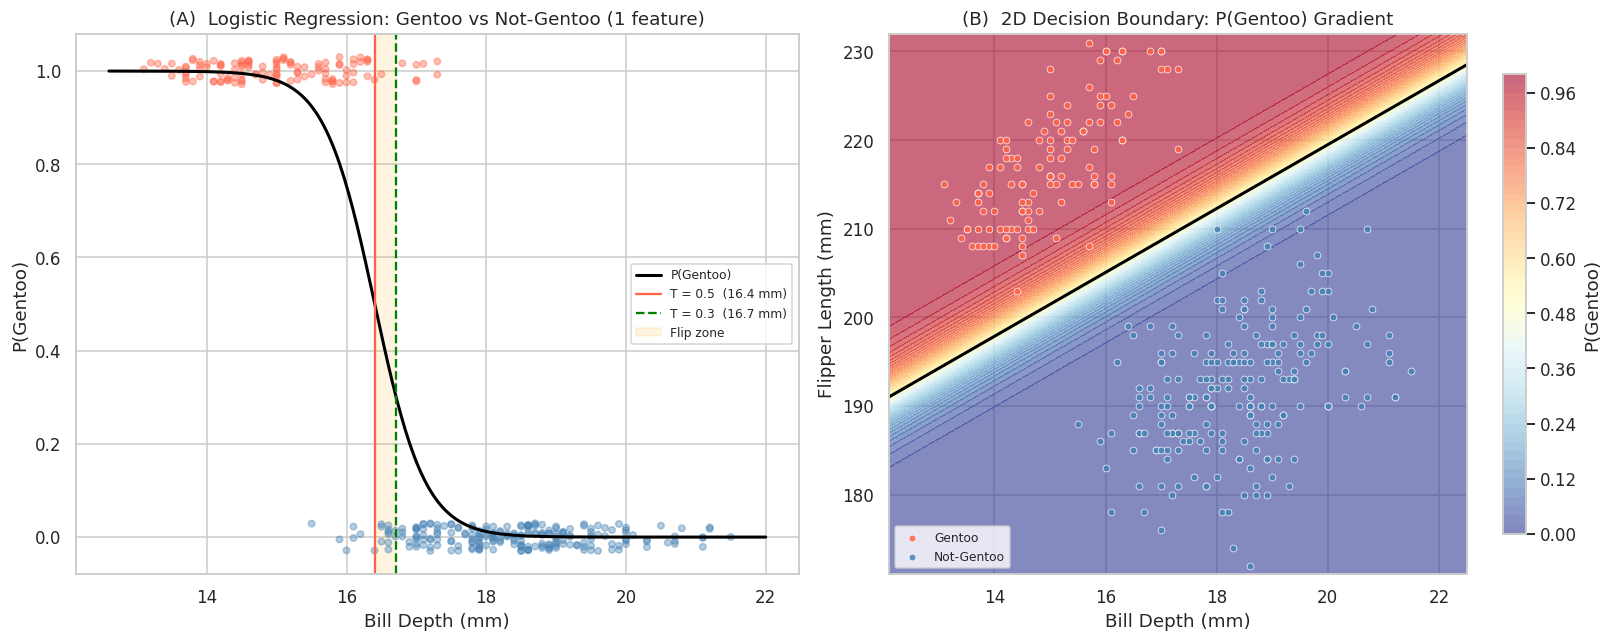

Panel (A) -- 1D model:
  w0 (intercept): 45.3713    w1 (bill_depth): -2.7658
  Boundary at T=0.5: bill_depth = 16.40 mm
  Boundary at T=0.3: bill_depth = 16.71 mm

  Confusion matrix at T=0.5  (rows=actual, cols=predicted):
               Pred 0    Pred 1
    Actual 0     207         7
    Actual 1       8       111

  Confusion matrix at T=0.3  (rows=actual, cols=predicted):
               Pred 0    Pred 1
    Actual 0     196        18
    Actual 1       7       112


Panel (B) -- 2D model:
  w0 (intercept): -72.1270
  w(bill_depth_mm): -1.7642
  w(flipper_length_mm): 0.4894
  Accuracy: 1.0000    Log-loss: 0.0034


In [9]:
# ============================================================
# DO NOT EDIT -- Q2 Figure (1x2): Run this cell, then answer
#                the questions below based on the two panels.
# ============================================================
penguins = sns.load_dataset('penguins').dropna().reset_index(drop=True)
is_gentoo = (penguins['species'] == 'Gentoo').astype(int).values

# --- Panel (A): 1D logistic regression on bill depth ---
X_bd = penguins[['bill_depth_mm']].values
lr1 = LogisticRegression(max_iter=1000).fit(X_bd, is_gentoo)
w0_1d, w1_1d = lr1.intercept_[0], lr1.coef_[0, 0]
proba1 = lr1.predict_proba(X_bd)[:, 1]

# Threshold boundary positions (analytical)
x_t05 = -w0_1d / w1_1d
x_t03 = (np.log(0.3 / 0.7) - w0_1d) / w1_1d

pred_05 = (proba1 >= 0.5).astype(int)
pred_03 = (proba1 >= 0.3).astype(int)

# --- Panel (B): 2D logistic regression ---
feat2 = ['bill_depth_mm', 'flipper_length_mm']
X_2d = penguins[feat2].values
lr2 = LogisticRegression(max_iter=1000).fit(X_2d, is_gentoo)
proba2 = lr2.predict_proba(X_2d)[:, 1]
pred_2d = lr2.predict(X_2d)

# ----------------------- 1x2 Figure -----------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
c_pts = np.where(is_gentoo, 'tomato', 'steelblue')

# --- Panel (A): Sigmoid + two thresholds ---
ax = axes[0]
jit = np.random.default_rng(7).uniform(-0.03, 0.03, len(is_gentoo))
ax.scatter(X_bd, is_gentoo + jit, alpha=0.4, s=18, c=c_pts, zorder=2)
xr = np.linspace(X_bd.min() - 0.5, X_bd.max() + 0.5, 300).reshape(-1, 1)
ax.plot(xr, lr1.predict_proba(xr)[:, 1], color='black', lw=2, label='P(Gentoo)')
ax.axvline(x_t05, color='tomato', lw=1.5, ls='-',
           label=f'T = 0.5  ({x_t05:.1f} mm)')
ax.axvline(x_t03, color='green', lw=1.5, ls='--',
           label=f'T = 0.3  ({x_t03:.1f} mm)')
lo, hi = min(x_t05, x_t03), max(x_t05, x_t03)
ax.axvspan(lo, hi, alpha=0.12, color='orange', label='Flip zone')
ax.set_xlabel('Bill Depth (mm)')
ax.set_ylabel('P(Gentoo)')
ax.set_title('(A)  Logistic Regression: Gentoo vs Not-Gentoo (1 feature)')
ax.legend(fontsize=8, loc='center right')
ax.set_ylim(-0.08, 1.08)

# --- Panel (B): 2D decision boundary ---
ax = axes[1]
mgn = 1
xx, yy = np.meshgrid(
    np.linspace(X_2d[:, 0].min() - mgn, X_2d[:, 0].max() + mgn, 300),
    np.linspace(X_2d[:, 1].min() - mgn, X_2d[:, 1].max() + mgn, 300))
Z = lr2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
cf = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 51),
                 cmap='RdYlBu_r', alpha=0.6)
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
fig.colorbar(cf, ax=ax, label='P(Gentoo)', shrink=0.85)
gentoo_m = is_gentoo == 1
ax.scatter(X_2d[gentoo_m, 0], X_2d[gentoo_m, 1], c='tomato',
           edgecolor='white', s=20, lw=0.5, alpha=0.85, zorder=3, label='Gentoo')
ax.scatter(X_2d[~gentoo_m, 0], X_2d[~gentoo_m, 1], c='steelblue',
           edgecolor='white', s=20, lw=0.5, alpha=0.85, zorder=3, label='Not-Gentoo')
mis = pred_2d != is_gentoo
if mis.sum() > 0:
    ax.scatter(X_2d[mis, 0], X_2d[mis, 1], facecolors='none',
               edgecolors='black', s=90, lw=1.5, zorder=4,
               label=f'Misclassified ({mis.sum()})')
ax.set_xlabel('Bill Depth (mm)')
ax.set_ylabel('Flipper Length (mm)')
ax.set_title('(B)  2D Decision Boundary: P(Gentoo) Gradient')
ax.legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.show()

# --- Printed summaries ---
print("Panel (A) -- 1D model:")
print(f"  w0 (intercept): {w0_1d:.4f}    w1 (bill_depth): {w1_1d:.4f}")
print(f"  Boundary at T=0.5: bill_depth = {x_t05:.2f} mm")
print(f"  Boundary at T=0.3: bill_depth = {x_t03:.2f} mm")
print()
for label, pred in [('T=0.5', pred_05), ('T=0.3', pred_03)]:
    cm = metrics.confusion_matrix(is_gentoo, pred)
    print(f"  Confusion matrix at {label}  (rows=actual, cols=predicted):")
    print(f"               Pred 0    Pred 1")
    print(f"    Actual 0    {cm[0,0]:>4d}      {cm[0,1]:>4d}")
    print(f"    Actual 1    {cm[1,0]:>4d}      {cm[1,1]:>4d}")
    print()
print()
print("Panel (B) -- 2D model:")
w0_2d = lr2.intercept_[0]
w_2d = lr2.coef_[0]
print(f"  w0 (intercept): {w0_2d:.4f}")
for name, w in zip(feat2, w_2d):
    print(f"  w({name}): {w:.4f}")
acc2 = metrics.accuracy_score(is_gentoo, pred_2d)
ll2 = metrics.log_loss(is_gentoo, proba2)
print(f"  Accuracy: {acc2:.4f}    Log-loss: {ll2:.4f}")

**Q2.A** -- Look at **Panel (A)**. The shaded band marks bill depths where the predicted class flips when the threshold drops from T=0.5 to T=0.3. Using the two printed confusion matrices, identify TP, FP, FN, and TN at each threshold, compute precision and recall for both, and explain why lowering the threshold trades one for the other. Connect your answer to the class overlap visible in the shaded region.

---

**Q2.B** -- Look at **Panel (B)**. The binary log-loss for one observation is:

$$L(y_i, \hat{p}_i) = -[y_i \ln(\hat{p}_i) + (1-y_i)\ln(1-\hat{p}_i)]$$

A penguin sits exactly on the decision boundary. Derive its predicted probability, then compute the log-loss for both $y=1$ and $y=0$. Show your work.

Now suppose we increase that penguin's `bill_depth_mm`. Does the loss increase or decrease for a Gentoo ($y=1$)? What about for a non-Gentoo ($y=0$)? Explain.

<div style="border-left: 4px solid #6366f1; padding: 14px 18px; margin: 16px 0; border-radius: 6px; background: rgba(99, 102, 241, 0.08);">

**Answer (A):**

T=0.5
True Positive: 111/333
False Positive: 7/333
False Negative: 8/333
True Negative: 207/333

Precision: 111/118
Recall: 111/119

T=0.3
True Positive: 112/333
False Positive: 18/333
False Negative: 7/333
True Negative: 196/333

Precision: 112/130
Recall: 112/119

When you reduce the threshold of classification this means you will have more false positives, but it can be done strategically if the necessary treatment for a positive result is important it might make more sense to over incentivize the model to classify as positive or false positive. Here the difference in threshold doesn't really change too much, it makes the precision a bit worse when the threshold is lowered.


---

**Answer (B):**

I've been trying to like workshop through the formula provided, I understand how the equation kind of zeros out here, but I can't put into words what log-loss really amounts to or conceptually mean. If we increase the bill_depth_mm that should decrease the loss for y=1 and not change the loss for y=0.

</div>

<div style="border: 2px solid #2563eb; border-radius: 8px; padding: 16px 20px; margin: 24px 0 12px 0; background: rgba(37, 99, 235, 0.04);">

## Q3

Run the cell below to generate a 1x2 figure, then answer Q3.A through Q3.C.

</div>

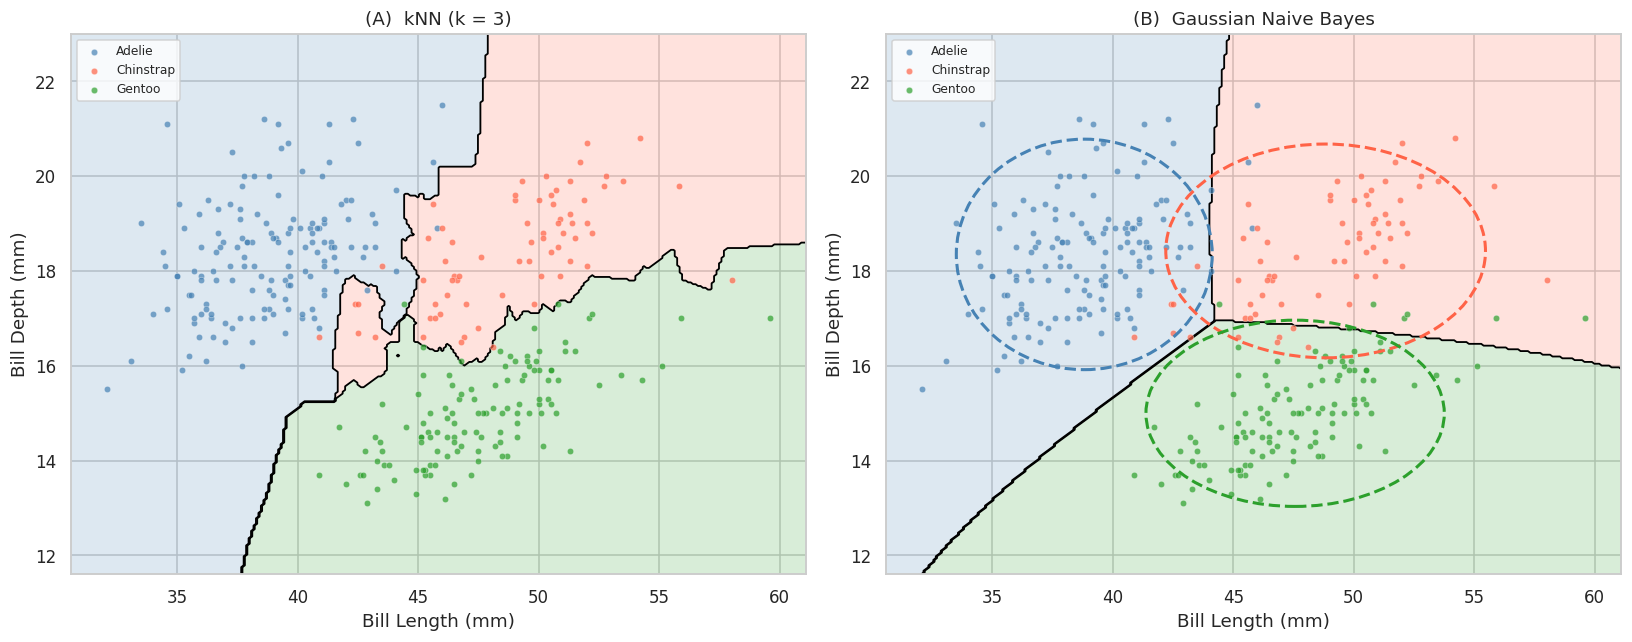

kNN (k=3)  --  Accuracy: 0.9760
  Confusion matrix (rows=actual, cols=predicted):
                  Adelie   Chinstrap    Gentoo
        Adelie       144           2         0
     Chinstrap         2          64         2
        Gentoo         1           1       117

Gaussian NB  --  Accuracy: 0.9309
  Confusion matrix (rows=actual, cols=predicted):
                  Adelie   Chinstrap    Gentoo
        Adelie       141           5         0
     Chinstrap         6          57         5
        Gentoo         0           7       112

Gaussian NB learned parameters:
  Adelie: mean=(38.82, 18.35)  std=(2.65, 1.22)
  Chinstrap: mean=(48.83, 18.42)  std=(3.31, 1.13)
  Gentoo: mean=(47.57, 15.00)  std=(3.09, 0.98)

Within-class sample correlations (bill_length vs bill_depth):
  Adelie: 0.3858
  Chinstrap: 0.6535
  Gentoo: 0.6540


In [5]:
# ============================================================
# DO NOT EDIT -- Q3 Figure (1x2): Run this cell, then answer
#                the question below based on the two panels.
# ============================================================
from matplotlib.patches import Ellipse

penguins_q3 = sns.load_dataset('penguins').dropna().reset_index(drop=True)
species_q3 = penguins_q3['species'].values
feat_q3 = ['bill_length_mm', 'bill_depth_mm']
X_q3 = penguins_q3[feat_q3].values
y_q3 = pd.Categorical(species_q3).codes  # 0=Adelie, 1=Chinstrap, 2=Gentoo
species_names = ['Adelie', 'Chinstrap', 'Gentoo']
colors_q3 = ['steelblue', 'tomato', '#2ca02c']

knn_q3 = KNeighborsClassifier(n_neighbors=3).fit(X_q3, y_q3)
gnb_q3 = GaussianNB().fit(X_q3, y_q3)

mgn = 1.5
xx_q3, yy_q3 = np.meshgrid(
    np.linspace(X_q3[:, 0].min() - mgn, X_q3[:, 0].max() + mgn, 300),
    np.linspace(X_q3[:, 1].min() - mgn, X_q3[:, 1].max() + mgn, 300))
grid_q3 = np.c_[xx_q3.ravel(), yy_q3.ravel()]
Z_knn = knn_q3.predict(grid_q3).reshape(xx_q3.shape)
Z_gnb = gnb_q3.predict(grid_q3).reshape(xx_q3.shape)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, Z, title in [(axes[0], Z_knn, '(A)  kNN (k = 3)'),
                      (axes[1], Z_gnb, '(B)  Gaussian Naive Bayes')]:
    ax.contourf(xx_q3, yy_q3, Z, alpha=0.18, levels=[-0.5, 0.5, 1.5, 2.5],
                colors=colors_q3)
    ax.contour(xx_q3, yy_q3, Z, levels=[0.5, 1.5], colors='black',
               linewidths=1.2, linestyles='-')
    for c, color, name in zip([0, 1, 2], colors_q3, species_names):
        mask = y_q3 == c
        ax.scatter(X_q3[mask, 0], X_q3[mask, 1], c=color, s=18, alpha=0.7,
                   edgecolor='white', lw=0.3, label=name, zorder=3)
    ax.set_xlabel('Bill Length (mm)')
    ax.set_ylabel('Bill Depth (mm)')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper left')

# Draw axis-aligned 2-sigma ellipses on Panel (B) for GNB
for c, color in zip([0, 1, 2], colors_q3):
    mu = gnb_q3.theta_[c]
    sd = np.sqrt(gnb_q3.var_[c])
    ell = Ellipse(mu, width=4*sd[0], height=4*sd[1], fill=False,
                  edgecolor=color, lw=2, ls='--', zorder=4)
    axes[1].add_patch(ell)

plt.tight_layout()
plt.show()

# --- Printed summaries ---
for label, model in [('kNN (k=3)', knn_q3), ('Gaussian NB', gnb_q3)]:
    pred = model.predict(X_q3)
    cm = metrics.confusion_matrix(y_q3, pred)
    acc = metrics.accuracy_score(y_q3, pred)
    print(f"{label}  --  Accuracy: {acc:.4f}")
    print(f"  Confusion matrix (rows=actual, cols=predicted):")
    print(f"  {'':>12s}  {'Adelie':>8s}  {'Chinstrap':>10s}  {'Gentoo':>8s}")
    for r, name in enumerate(species_names):
        print(f"  {name:>12s}  {cm[r,0]:>8d}  {cm[r,1]:>10d}  {cm[r,2]:>8d}")
    print()
print("Gaussian NB learned parameters:")
for c, name in enumerate(species_names):
    mu = gnb_q3.theta_[c]
    sd = np.sqrt(gnb_q3.var_[c])
    print(f"  {name}: mean=({mu[0]:.2f}, {mu[1]:.2f})  std=({sd[0]:.2f}, {sd[1]:.2f})")
print()
print("Within-class sample correlations (bill_length vs bill_depth):")
for c, name in enumerate(species_names):
    mask = y_q3 == c
    corr = np.corrcoef(X_q3[mask, 0], X_q3[mask, 1])[0, 1]
    print(f"  {name}: {corr:.4f}")

**Q3.A** -- The dashed ellipses in Panel (B) show the per-class Gaussian contours that the model learned. Looking at Panel (B) and the printed within-class sample correlations, what modeling assumption do the ellipses reveal, and how can you tell from the data that this assumption is violated?

---

**Q3.B** -- Compare the two confusion matrices. Which species suffers the largest accuracy drop when switching from kNN to Gaussian NB? Explain why, connecting your answer from Q3.A to that species' position in the feature space.

---

**Q3.C** -- The product team wants to ship one of these classifiers in a mobile app where users input penguin measurements to identify the species. Which classifier do you recommend and why?

<div style="border-left: 4px solid #6366f1; padding: 14px 18px; margin: 16px 0; border-radius: 6px; background: rgba(99, 102, 241, 0.08);">

**Answer (A):**

Looking at the contours we see that this model overlapped the classification ellipses. In the Gaussian NB model there are more error classifications in the output and the accuracy is lower. 

---

**Answer (B):**

The Chinstrap penguin has 7 more misclassified instances in the Gaussian NB model than the kNN model. By being the section of the Gaussian NB model that overlaps with the other two models, it loses data more than the other 2 classes.

---

**Answer (C):**

I would want to ship the kNN k=3 model over the Gaussian NB model, with a higher accuracy and it being a more simple kNN model than Gaussian, I would recommend the kNN classifier.

</div>

<div style="border: 2px solid #2563eb; border-radius: 8px; padding: 16px 20px; margin: 24px 0 12px 0; background: rgba(37, 99, 235, 0.04);">

## Q4

Answer Q4.A and Q4.B below.

</div>

Recall the soft-margin SVM optimization:

$$
\min_{\mathbf{w},\, b,\, \xi} \quad \frac{1}{2}\|\mathbf{w}\|^2 \;+\; C \sum_{i=1}^{n} \xi_i
$$

$$
\text{subject to:} \quad y_i\,(\mathbf{w}^T \mathbf{x}_i + b) \;\ge\; 1 - \xi_i, \qquad \xi_i \ge 0
$$

where $\xi_i = \max\!\big(0,\; 1 - y_i(\mathbf{w}^T \mathbf{x}_i + b)\big)$ is the slack variable for point $i$, and the margin width is $\frac{2}{\|\mathbf{w}\|}$.

---

**Q4.A** -- Consider a trained soft-margin SVM on a dataset where the two classes overlap.

**(A1)** Suppose you increase $C$ by a large factor. Explain what happens to $\|\mathbf{w}\|$, the margin width, and $\sum \xi_i$. For each, state the direction of change and *why* the optimizer makes that trade-off.

**(A2)** In the extreme case $C \to \infty$, what optimization problem does the soft-margin formulation reduce to? Under what data condition would this problem have no feasible solution?

---

**Q4.B** -- A linear SVM is trained on 100 data points with $C = 1$. The solution has $\|\mathbf{w}\| = 2.2$ and exactly 24 support vectors.

Among those 24 support vectors, some have $\xi_i = 0$, some have $0 < \xi_i < 1$, and some have $\xi_i \ge 1$. For each of these three groups, describe where the corresponding point lies relative to the decision boundary and the margin boundaries. State whether it is correctly or incorrectly classified.

<div style="border-left: 4px solid #6366f1; padding: 14px 18px; margin: 16px 0; border-radius: 6px; background: rgba(99, 102, 241, 0.08);">

**Answer (A1):**

A large C value means that the margin will be very small it will possibly overfit the data or maybe not find a proper model at all depending on how large the C value is and how dispersed the data is. The error penalty will be higher for the slack term. The optimizer wants to minimize the overall value so the w term will become smaller as a result of larger slack term values and it still probably won't optimize unless the data is kind of split already.

**Answer (A2):**

Like I kind of said in the last point, this almost become linear regression with an infinite C value because it will try to find a way for the line to fit where it doesn't misclassify or incur any penalties from the data. It would have no feasible solution if there was not a way to cleanly split the data without misclassifications.

---

**Answer (B):**

For slack term = 0, this will be exactly on the SVM line, for a slack term 0 < x < 1, this means that the data point is within the margain of the SVM could be slightly misclassified but close, then if the term is = 1 that would mean it is a support vector and it is exactly on the margin lines of the SVM, finally if the term is greater than 1 that means the point is misclassified.

</div>

<div style="border: 2px solid #2563eb; border-radius: 8px; padding: 16px 20px; margin: 24px 0 12px 0; background: rgba(37, 99, 235, 0.04);">

## Q6

Run the cell below to display three decision trees from a Random Forest, then answer below.

</div>

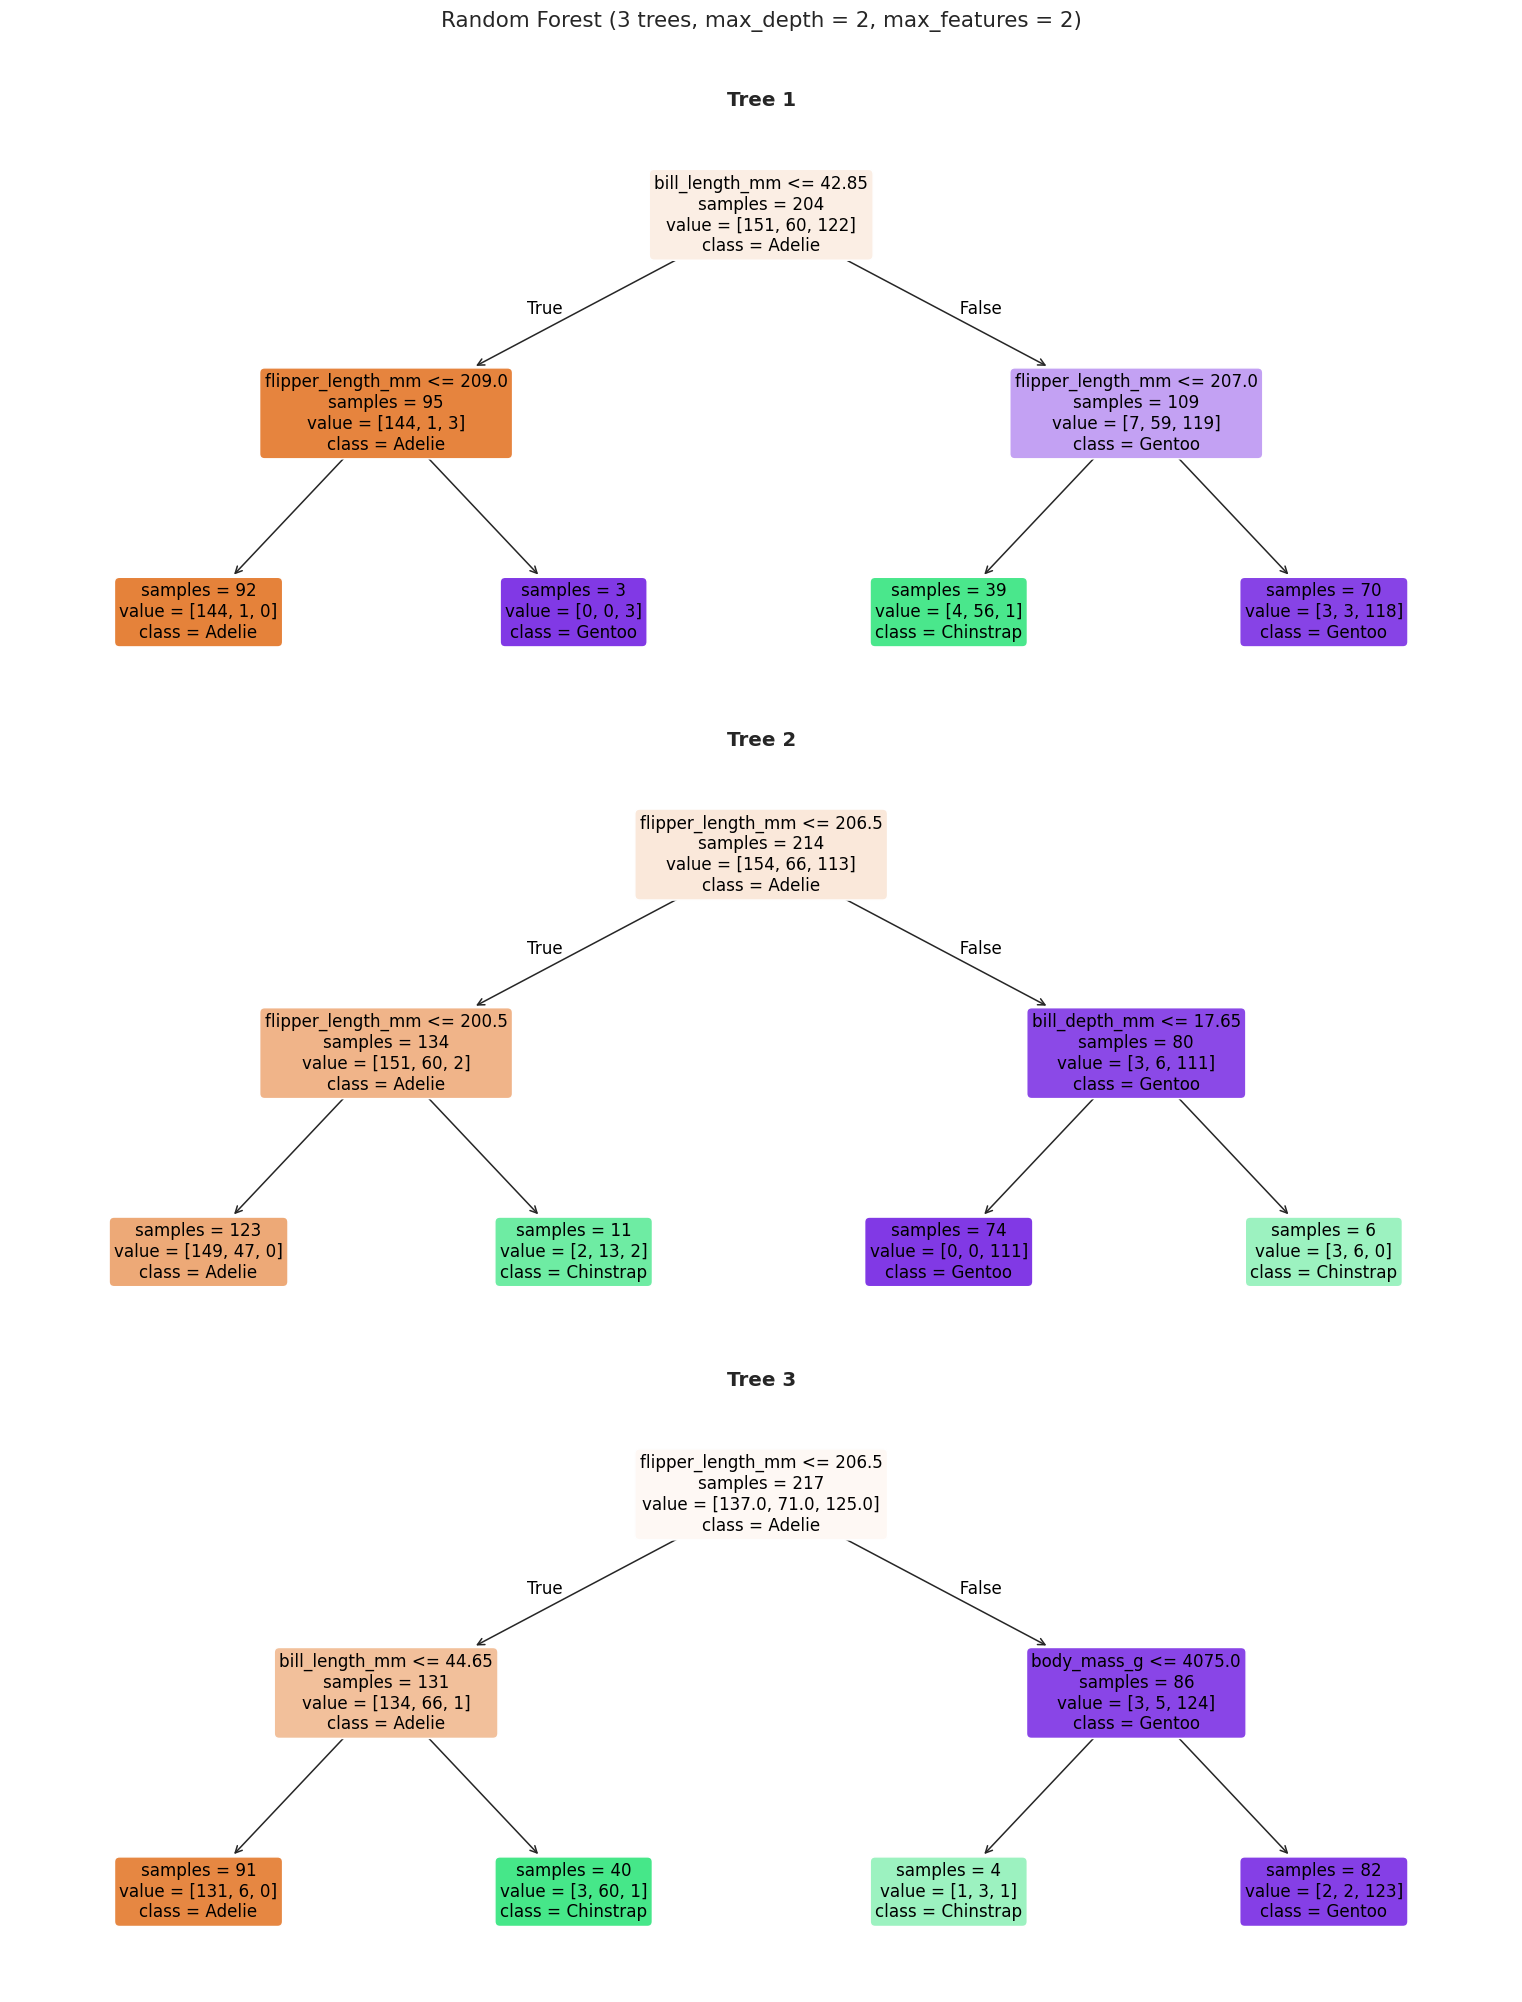

New penguin to classify:
  bill_length_mm    = 46.5
  bill_depth_mm     = 17.9
  flipper_length_mm = 192.0
  body_mass_g       = 3500.0


In [6]:
# ============================================================
# DO NOT EDIT -- Q6 Figure: Run this cell, then answer below.
# ============================================================
penguins_q6 = sns.load_dataset('penguins').dropna()
features_q6 = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X_q6 = penguins_q6[features_q6].values
y_q6 = penguins_q6['species'].values

rf = RandomForestClassifier(n_estimators=3, max_depth=2, max_features=2,
                            bootstrap=True, random_state=10)
rf.fit(X_q6, y_q6)

class_names_q6 = ['Adelie', 'Chinstrap', 'Gentoo']
fig, axes = plt.subplots(3, 1, figsize=(14, 18))
for i, (ax, tree) in enumerate(zip(axes, rf.estimators_)):
    plot_tree(tree, ax=ax, feature_names=features_q6, class_names=class_names_q6,
              filled=True, rounded=True, fontsize=11, impurity=False,
              proportion=False)
    ax.set_title(f'Tree {i+1}', fontsize=13, fontweight='bold')
    # Dark font on light background for readability
    for text_obj in ax.texts:
        text_obj.set_color('black')
        text_obj.set_fontweight('normal')
plt.suptitle('Random Forest (3 trees, max_depth = 2, max_features = 2)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("New penguin to classify:")
print("  bill_length_mm    = 46.5")
print("  bill_depth_mm     = 17.9")
print("  flipper_length_mm = 192.0")
print("  body_mass_g       = 3500.0")

**Q6** -- A new penguin arrives with the measurements shown above. Trace the path through each of the three trees in the figure (state the feature test and direction at every internal node) and write each tree's predicted species. Then give the Random Forest's final prediction and explain how it is determined.

<div style="border-left: 4px solid #6366f1; padding: 14px 18px; margin: 16px 0; border-radius: 6px; background: rgba(99, 102, 241, 0.08);">

Tree 1: Chinstrap (False, True)
Tree 2: Adelie (True, True)
Tree 3: Chinstrap (True, False)

The Random Forest would conclude that the penguin is a Chinstrap, it takes the group majority answer based on randomized feature decision trees and proclaims that to be the classification



</div>

<div style="border: 2px solid #2563eb; border-radius: 8px; padding: 16px 20px; margin: 24px 0 12px 0; background: rgba(37, 99, 235, 0.04);">

## Q7

Answer Q7 below.

</div>

Recall the AdaBoost ensemble prediction and voting weight:

$$
\hat{y}(x) = \text{sign}\!\left(\sum_{m=1}^{M} \alpha_m \, \hat{y}_m(x)\right)
\qquad \text{where} \qquad
\alpha_m = \ln\!\left(\frac{1 - \epsilon_m}{\epsilon_m}\right)
$$

and $\epsilon_m = \sum_{i=1}^{n} w_i \cdot \mathbb{1}[\hat{y}_m(x_i) \neq y_i]$ is the weighted error of stump $m$.

---

**Q7** -- Three stumps are trained sequentially. Their weighted errors on the current sample distribution are $\epsilon_1 = 0.10$, $\epsilon_2 = 0.45$, and $\epsilon_3 = 0.50$.

Compute $\alpha_m$ for each stump. Then explain:

- Based on $\alpha_3$, what happens to the third stump's contribution in the ensemble? Explain why.
- If a hypothetical fourth stump achieved $\epsilon_4 = 0.60$, what would $\alpha_4$ be? What effect would this $\alpha$ have on that stump's contribution to the final sign vote?

<div style="border-left: 4px solid #6366f1; padding: 14px 18px; margin: 16px 0; border-radius: 6px; background: rgba(99, 102, 241, 0.08);">

am(0.1) = ln(9)
am(0.45) = ln(.55/.45)
am(0.50) = 1

Because alpham(0.5) = 1, This means it will a strong contributor to the ensemble. alpha = 0 is like as good as guessing, 1 is a good parameter, and greater than that gets even more contribution.

If a hypothetical fourth stump achieved 0.6 a4(0.6) = ln(2/3), this will be a negative value, which literally predicts worse than random guessing, meaning it won't have as much weight in the final collaborative decision.

</div>

<div style="border: 2px solid #2563eb; border-radius: 8px; padding: 16px 20px; margin: 24px 0 12px 0; background: rgba(37, 99, 235, 0.04);">

## Q8

Run the cell below, then answer Q8.

</div>

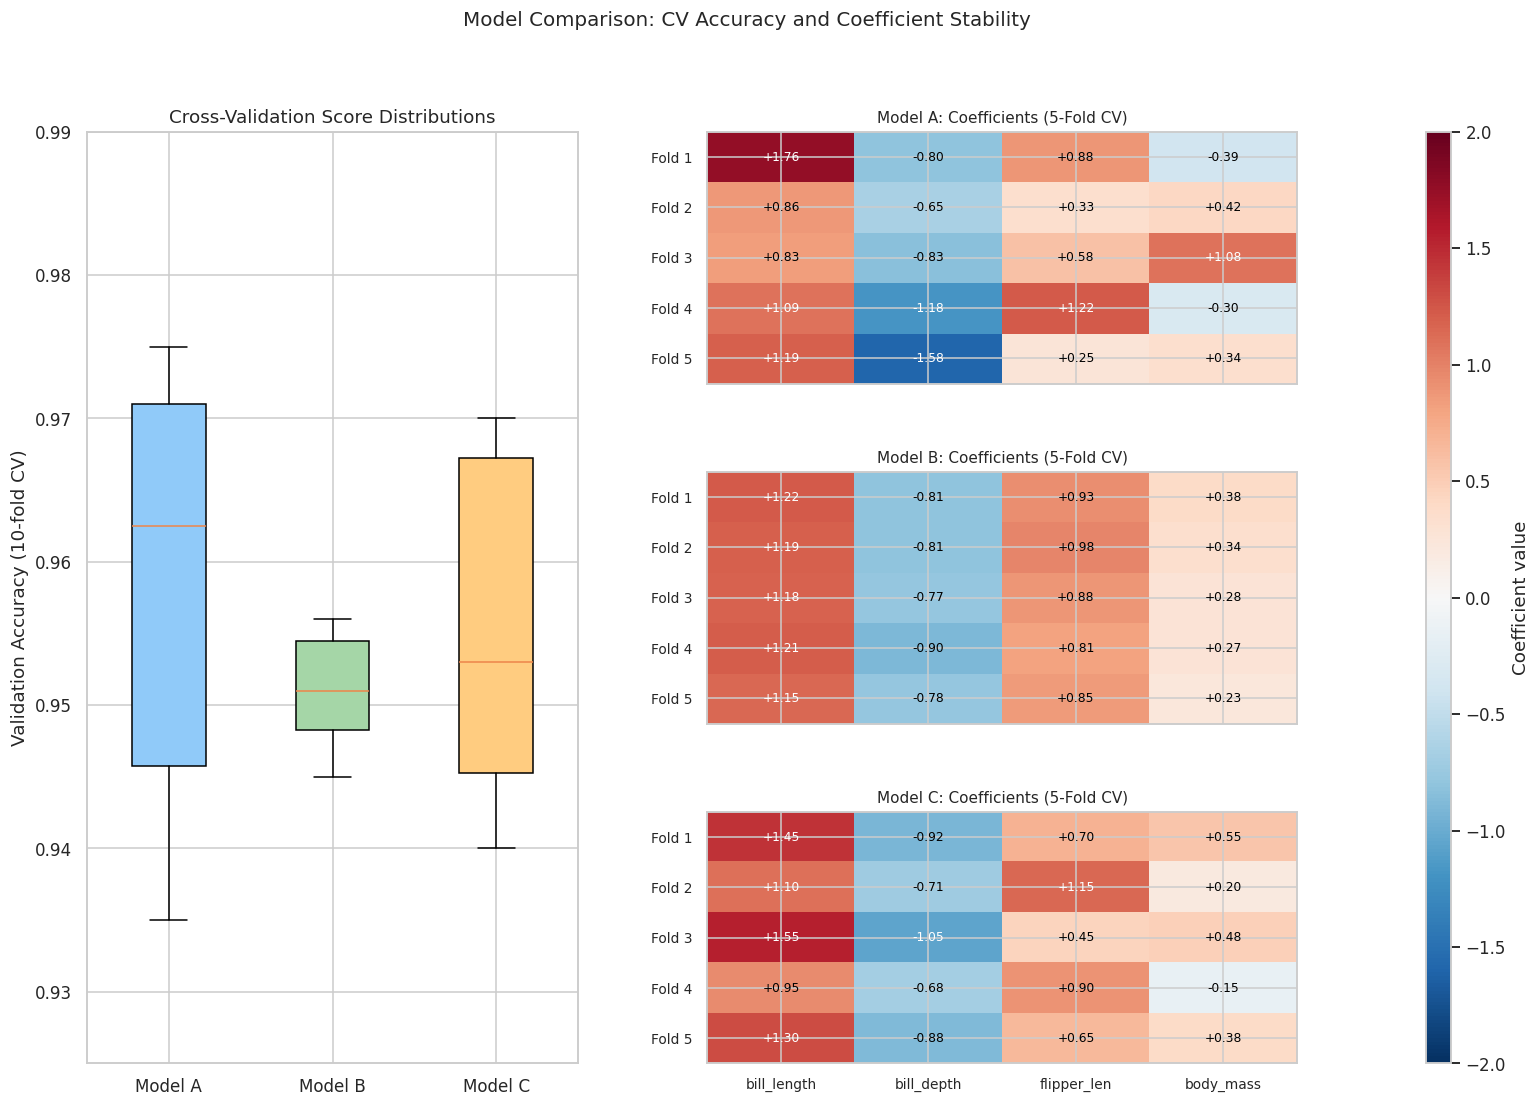

10-Fold CV Summary:
    Model   Mean    Std    Min    Max   Median
  Model A  0.958  0.014  0.935  0.975  0.962
  Model B  0.951  0.004  0.945  0.956  0.951
  Model C  0.955  0.011  0.940  0.970  0.953

Per-feature std of coefficients across 5 folds:
       Feature   Model A   Model B   Model C
   bill_length   0.336     0.024     0.220
    bill_depth   0.335     0.046     0.137
   flipper_len   0.359     0.060     0.238
     body_mass   0.536     0.053     0.250


In [7]:
# ============================================================
# DO NOT EDIT -- Q8 Figure: Run this cell, then answer below.
# ============================================================
import matplotlib.gridspec as gridspec

# --- 10-fold CV accuracy scores ---
scores_A = np.array([0.965, 0.940, 0.975, 0.945, 0.968, 0.935, 0.960, 0.972, 0.948, 0.972])
scores_B = np.array([0.948, 0.955, 0.945, 0.950, 0.956, 0.953, 0.947, 0.952, 0.955, 0.949])
scores_C = np.array([0.965, 0.945, 0.970, 0.940, 0.968, 0.942, 0.958, 0.968, 0.948, 0.946])

# --- Learned coefficients across 5-fold CV ---
features_q8 = ['bill_length', 'bill_depth', 'flipper_len', 'body_mass']
fold_labels = [f'Fold {i+1}' for i in range(5)]

coefs_A = np.array([
    [+1.76, -0.80, +0.88, -0.39],
    [+0.86, -0.65, +0.33, +0.42],
    [+0.83, -0.83, +0.58, +1.08],
    [+1.09, -1.18, +1.22, -0.30],
    [+1.19, -1.58, +0.25, +0.34],
])
coefs_B = np.array([
    [+1.22, -0.81, +0.93, +0.38],
    [+1.19, -0.81, +0.98, +0.34],
    [+1.18, -0.77, +0.88, +0.28],
    [+1.21, -0.90, +0.81, +0.27],
    [+1.15, -0.78, +0.85, +0.23],
])
coefs_C = np.array([
    [+1.45, -0.92, +0.70, +0.55],
    [+1.10, -0.71, +1.15, +0.20],
    [+1.55, -1.05, +0.45, +0.48],
    [+0.95, -0.68, +0.90, -0.15],
    [+1.30, -0.88, +0.65, +0.38],
])

# ----------------------- Combined Figure -----------------------
fig = plt.figure(figsize=(16, 11))
gs = gridspec.GridSpec(3, 3, width_ratios=[1, 1.2, 0.05],
                       hspace=0.35, wspace=0.35)

# --- Left: Box plot (spans all 3 rows) ---
ax_box = fig.add_subplot(gs[:, 0])
bp = ax_box.boxplot([scores_A, scores_B, scores_C],
                     tick_labels=['Model A', 'Model B', 'Model C'],
                     patch_artist=True, widths=0.45)
box_colors = ['#90caf9', '#a5d6a7', '#ffcc80']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
ax_box.set_ylabel('Validation Accuracy (10-fold CV)')
ax_box.set_title('Cross-Validation Score Distributions')
ax_box.set_ylim(0.925, 0.99)

# --- Right: Coefficient heatmaps (stacked) ---
hm_axes = []
for idx, (name, coefs) in enumerate([
    ('Model A', coefs_A), ('Model B', coefs_B), ('Model C', coefs_C)]):
    ax = fig.add_subplot(gs[idx, 1])
    hm_axes.append(ax)
    im = ax.imshow(coefs, cmap='RdBu_r', vmin=-2, vmax=2, aspect='auto')
    ax.set_xticks(range(4))
    ax.set_xticklabels(features_q8 if idx == 2 else [], fontsize=9)
    ax.set_yticks(range(5))
    ax.set_yticklabels(fold_labels, fontsize=9)
    ax.set_title(f'{name}: Coefficients (5-Fold CV)', fontsize=10)
    for i in range(5):
        for j in range(4):
            ax.text(j, i, f'{coefs[i,j]:+.2f}', ha='center', va='center',
                    fontsize=8,
                    color='white' if abs(coefs[i,j]) > 1.0 else 'black')

cbar_ax = fig.add_subplot(gs[:, 2])
fig.colorbar(im, cax=cbar_ax, label='Coefficient value')

plt.suptitle('Model Comparison: CV Accuracy and Coefficient Stability',
             fontsize=13, y=0.98)
plt.show()

# --- Printed summaries ---
print("10-Fold CV Summary:")
print(f"{'Model':>9s}   Mean    Std    Min    Max   Median")
for name, s in [('A', scores_A), ('B', scores_B), ('C', scores_C)]:
    print(f"  Model {name}  {s.mean():.3f}  {s.std():.3f}  {s.min():.3f}  {s.max():.3f}  {np.median(s):.3f}")
print()
print("Per-feature std of coefficients across 5 folds:")
print(f"  {'Feature':>12s}   Model A   Model B   Model C")
for j, f in enumerate(features_q8):
    print(f"  {f:>12s}   {coefs_A[:,j].std():.3f}     {coefs_B[:,j].std():.3f}     {coefs_C[:,j].std():.3f}")

**Q8** -- You must select one of these three models for deployment. The deployed model will encounter data that may differ slightly from the training distribution.

Using both the box plots (left) and the coefficient heatmaps (right), which model would you choose? Justify by discussing mean accuracy, consistency of CV scores, and stability of the learned coefficients. Explain what risk(s) your rejected models carry.

<div style="border-left: 4px solid #6366f1; padding: 14px 18px; margin: 16px 0; border-radius: 6px; background: rgba(99, 102, 241, 0.08);">

For 1 thing to point out first all of the models doesn't say if data was stratified, so it could be a bit underfit to the original dataset.

Model A scares me. The standard deviation is far higher than the other 2 models, so if the new data is slightly different it would be hard to be confident in predicting top notch results. Although it does have the highest mean, median, and max summary statistics I don't think it makes the most sense long term for a new dataset.

Model B I actually like. I feel like this is a case where having lower std div would be better going into a new different dataset to test. Because at worst, something like gradient boosting could be carried out later in order to adjust for the slight bias away from perfection model B seems to have. The mean is only 0.007 different than the mean of the higher maximum performance model, model A. 

Model C is enticing. The main thing with model C is that the median is quite low which means that most of the data is actually on the upper half of the range. This could have been a result of a couple extreme folds having more leverage on the accuracy metrics.

Overall, I think stratifying the data and using model C would be my selection for this instance.

</div>